# Recommender System

### Recommender Architecture

We choose the cosine similarity distance as our metric of how similar two games are. This is a standard approach to content-based RS and we stick to it. It is defined using the simple dot-product. This ensures that games that have way too many tags are not weighed any higher than another game with only four good quality tags (this is beacuse the cosine similarity involves normalizing the dot-product to nullify the effect of "long" vectors). 

**High-level overview of the Recommender System**:

1. The user will input three games and the RS will output 10 similar games, 2 of which are free to play.
2. The features of the input games will be converted to a similarity matrix and it's distance to all games in a subset of df_topten will be calculated using cosine similarity.
3. Games to be recommended will be ranked by cosine distance (top games have the largest cosine similarity).
4. The top 8 paid games and the top 2 free to play games will be output as the recommendations.

We'll justify the choice of the ratio 8:2 for paid and free to play games games below.  

**Under the hood**: We actually construct two recommender systems: one will recommend 8 paid games and the other, 2 free to play games. Constructing two recommender systems is necessary since the features used to recommend paid games are not the same as the ones used to recommend free games. 

### Dataset Filtering: Cr&egrave;me de la Cr&egrave;me

Not every game is worth recommending! We now slice off our dataset to create a dataframe that contains the games we actually wish to recommend. So we must decide the best games using an objective metric. Thankfully, we've already done all the hard work at creating such a metric. 

Our main indicator of a game's quality is Bayesian votes. It is implausible that we recommend games with no votes or in general, a low Bayesian votes score. At the same time, we wish to use a small subset of the dataframe to recommend games. We choose to recommend games from the top 10% of games ordered by Bayesian votes. This will give us a healthy number of games (~11k) to recommend from while still being a small and a "premium" subset of the dataset, aka., cr&egrave;me de la cr&egrave;me. 

In [442]:
df['Bayesian votes'].describe()

count    106323.000000
mean          0.642306
std           0.155311
min           0.105009
25%           0.512994
50%           0.619887
75%           0.770505
max           0.995773
Name: Bayesian votes, dtype: float64

In [443]:
int(len(df) * 0.10)

10632

In [444]:
df.iloc[11445, 0] 

'Paleo Pines'

The game Paleo Pines is at the edge of our 10% quality cutoff. Heading over to its [Steam webpage](https://store.steampowered.com/app/1202200/Paleo_Pines/), we see that we most certainly want to recommend games better than this one. This tells us that our cutoff is chosen appropriately. 

In [445]:
# Define a new dataframe that consists of the top 10% games by Bayesian votes.

threshold = df['Bayesian votes'].quantile(0.90)

df_topten = df[df['Bayesian votes'] >= threshold].copy()

In [446]:
len(df_topten)

10633

We now break up df_topten into two dataframes, one to recommend paid games from and another to recommend free to play games from. 

In [447]:
# Calculate the percentage of free to play games in the df_topten dataframe.

len(df_topten.loc[df['Price'] == 0]) / len(df_topten) * 100

9.7808708736951

**Why 8:2?**: Since about 10% of games in df_topten are free to play, we could recommend 1 free to play games and 9 paid games. However, to give the user the option to explore free games similar to the ones they like, we recommend 2 free to play games instead of 1. In this way, they might consider paying for other paid recommended games once they trust the recommender system to give them meaningful recommendations. 

We crerate two dataframes from df_topten: df_paid_topten and df_free_topten. 

In [448]:
# Dataframe to recommend paid games.
df_paid_topten = df_topten[df_topten['Price'] != 0].copy()

# Dataframe to recommend free games.
df_free_topten = df_topten[df_topten['Price'] == 0].copy()

# We'll save these as csv so that we can use them when we deploy our app on Streamlit. 
df_paid_topten.to_csv('data/df_paid_topten.csv', index=False)
df_free_topten.to_csv('data/df_free_topten.csv', index=False)

Let's look at the heads of these new datasets.

In [449]:
df_paid_topten.head()

,Name,Release date,Estimated owners,Price,DLC count,Header image,Median playtime forever,Categories,Genres,Tags,Game age,Website,Estimated yearly revenue,Bayesian votes,Characteristics
1,Kabuto Park,2025-05-28,0.555777,3.99,1,https://shared.akamai.steamstatic.com/store_it...,153,"Single-player,Steam Achievements,Steam Trading...","Casual,Indie,RPG,Simulation,Strategy","Casual,Creature Collector,Nature,Cozy,Cute,Car...",0.94,https://store.steampowered.com/app/3376990/,0.549027,0.995773,rpg touchonlyoption coloralternatives customvo...
3,A Castle Full of Cats,2022-11-09,0.633077,2.39,1,https://shared.akamai.steamstatic.com/store_it...,131,"Single-player,Steam Achievements,Steam Trading...","Adventure,Casual","Cats,Hidden Object,Wholesome,Point & Click,Coz...",3.49,https://store.steampowered.com/app/2070550/,0.532016,0.993424,metroidvania pointandclick handdrawn vampire r...
4,A Tower Full of Cats,2024-05-20,0.555777,4.19,1,https://shared.akamai.steamstatic.com/store_it...,293,"Single-player,Steam Achievements,Steam Trading...","Adventure,Casual","Cats,Hidden Object,Puzzle,Point & Click,Creatu...",1.96,https://store.steampowered.com/app/2179170/,0.517405,0.993214,alternatehistory pointandclick historical hand...
5,Beastieball,2024-11-12,0.555777,21.24,1,https://shared.akamai.steamstatic.com/store_it...,260,"Single-player,Multi-player,PvP,Online PvP,Stea...","Adventure,Indie,RPG,Sports,Early Access","Early Access,Creature Collector,Sports,Turn-Ba...",1.48,https://store.steampowered.com/app/1864950/,0.605188,0.992843,controller onlinepvp openworld rpg coloraltern...
6,Papa's Freezeria Deluxe,2023-03-31,0.678083,4.79,0,https://shared.akamai.steamstatic.com/store_it...,346,"Single-player,Steam Achievements,Steam Cloud,F...","Action,Casual,Indie,Simulation,Strategy","Cooking,Time Management,Simulation,Job Simulat...",3.10,https://store.steampowered.com/app/2291760/,0.608594,0.992279,management cooking nostalgia cute jobsimulator...


In [450]:
df_free_topten.head()

,Name,Release date,Estimated owners,Price,DLC count,Header image,Median playtime forever,Categories,Genres,Tags,Game age,Website,Estimated yearly revenue,Bayesian votes,Characteristics
2,The WereCleaner,2024-05-07,0.678083,0.0,1,https://shared.akamai.steamstatic.com/store_it...,0,"Single-player,Steam Achievements,Full controll...","Action,Casual,Indie,Strategy,Free To Play","Stealth,Casual,Cartoony,Dark Humor,Strategy,Cu...",2.00,https://store.steampowered.com/app/2795000/,0.0,0.994034,3d comedy controller actionadventure arcade we...
16,HoloCure - Save the Fans!,2023-08-16,0.755384,0.0,0,https://shared.akamai.steamstatic.com/store_it...,0,"Single-player,Steam Achievements,Partial Contr...","Action,Adventure,Casual,Indie","Pixel Graphics,Bullet Hell,Anime,Action Roguel...",2.72,https://store.steampowered.com/app/2420510/,0.0,0.990356,fishing comedy pixelgraphics scoreattack arcad...
18,Buy a Croquette!,2024-04-27,0.633077,0.0,2,https://shared.akamai.steamstatic.com/store_it...,230,"Single-player,Steam Achievements,Full controll...","Adventure,Casual,Indie,RPG,Strategy,Free To Play","RPGMaker,Mystery,Sci-fi,Puzzle,Psychological H...",2.02,https://store.steampowered.com/app/2167960/,0.0,0.989689,controller pixelgraphics rpg drama visualnovel...
32,Our Life: Beginnings & Always,2020-11-16,0.718566,0.0,9,https://shared.akamai.steamstatic.com/store_it...,461,"Single-player,Steam Achievements","Casual,Indie,Free To Play","Visual Novel,Romance,LGBTQ+,Character Customiz...",5.47,https://store.steampowered.com/app/1129190/,0.0,0.988008,comedy replayvalue otome datingsim relaxing dr...
40,Word Game: Episode 0,2021-01-14,0.633077,0.0,0,https://shared.akamai.steamstatic.com/store_it...,36,Single-player,"Adventure,Indie,RPG,Strategy","Minimalist,Indie,Pixel Graphics,Puzzle,Free to...",5.31,https://store.steampowered.com/app/1507970/,0.0,0.986929,pixelgraphics rpg noir narration linear magic ...


**Recommender 1**: Recommending Paid Games: This recommender will use the features Characteristics, Bayesian votes and Estimated yearly revenue and recommend 8 games from the dataframe df_paid_topten.

**Recommender 2**: Recommending Free Games: This recommender will use the features Characteristics, Bayesian votes and Estimated owners and recommend 2 games from the dataframe df_free_topten.

### Weighting the features

We need to decide how strongly the selected features influence our RS. For this purpose, we need to check how correlated they are. The only pairs we need to check are how Bayesian votes is correlated with Estimated yearly revenue (for Recommender 1) and how Bayesian votes is correlated with Estimated with Estimated owners (for Recommender 2). 

In [451]:
pearson_corr = df_paid_topten['Bayesian votes'].corr(df_paid_topten['Estimated yearly revenue'], method='pearson')
spearman_corr = df_paid_topten['Bayesian votes'].corr(df_paid_topten['Estimated yearly revenue'], method='spearman')

print(f"Pearson Correlation (linear) between Bayesian votes and Estimated yearly revenue is: {pearson_corr:.4f}")  
print(f"Spearman Correlation (rank) between Bayesian votes and Estimated yearly revenue is: {spearman_corr:.4f}")

Pearson Correlation (linear) between Bayesian votes and Estimated yearly revenue is: 0.2235
Spearman Correlation (rank) between Bayesian votes and Estimated yearly revenue is: 0.2060


In [452]:
pearson_corr = df_free_topten['Bayesian votes'].corr(df_free_topten['Estimated owners'], method='pearson')
spearman_corr = df_free_topten['Bayesian votes'].corr(df_free_topten['Estimated owners'], method='spearman')

print(f"Pearson Correlation (linear) between Bayesian votes and Estimated owners is: {pearson_corr:.4f}")  
print(f"Spearman Correlation (rank) between Bayesian votes and Estimated owners is: {spearman_corr:.4f}")

Pearson Correlation (linear) between Bayesian votes and Estimated owners is: 0.1634
Spearman Correlation (rank) between Bayesian votes and Estimated owners is: 0.1971


**Verdict**: This is incredibly surprising. One would expect highly rated games to also have generated some of the highest revenue and vice versa, but that is not the case. We conclude that these features are independent and therefore, we weigh them accordingly.

**Weights**: We'll weigh Characteristics 50%, Bayesian votes 40% and Estimated yearly revenue 10% (Estimated owners 10% for Recommender 2). The reasoning: we want to find games that are similar mainly by how they "feel" when played. Characteristics captures this exact DNA of the game. Next, we weigh Bayesian votes significanlty higher than Estimated yearly revenue (and Estimated owners) for two reasons. One, Bayesian votes is a relatievly far more robust and objective metric of a game's quality, and second, recall that Estimated owners (and therefore, Estimated yearly revenue) is a very crude estimate of a game's (financial) performance. Therefore, Estimated yearly revenue / Estimated owners should get a say, but only a whisper. 

In [453]:
# 0. Fit the vectorizer only once on the master vocabulary.
char_vectorizer.fit(df_topten['Characteristics'].fillna(''))


# I. Matrix for paid games (Using 50/40/10 weights)


# Transform (uses the master vocabulary)
char_sparse_paid = char_vectorizer.transform(df_paid_topten['Characteristics'].fillna(''))
char_weighted_paid = char_sparse_paid * np.sqrt(0.5)

# Extract and weight votes & revenue.
votes_weighted_paid = (df_paid_topten['Bayesian votes'].values * np.sqrt(0.4)).reshape(-1, 1) # reshape(-1,1) converts a 1d matrix to 2d so that hstack works correctly.
revenue_weighted_paid = (df_paid_topten['Estimated yearly revenue'].values * np.sqrt(0.1)).reshape(-1, 1)

# Stack to create the paid master feature matrix.
X_paid = hstack([char_weighted_paid, votes_weighted_paid, revenue_weighted_paid]).tocsr()


# II. Matrix for free games (Using 50/40/10 weights)


# Transform (uses the master vocabulary).
char_sparse_free = char_vectorizer.transform(df_free_topten['Characteristics'].fillna(''))
char_weighted_free = char_sparse_free * np.sqrt(0.5)

# Extract and weight votes & owners.
votes_weighted_free = (df_free_topten['Bayesian votes'].values * np.sqrt(0.4)).reshape(-1, 1)
owners_weighted_free = (df_free_topten['Estimated owners'].values * np.sqrt(0.1)).reshape(-1, 1)

# Stack to create the free master feature matrix.
X_free = hstack([char_weighted_free, votes_weighted_free, owners_weighted_free]).tocsr()

## Constructing the Recommender

At long last, we construct our actual recommender. 

In [454]:
def recommend_games(input_titles, df_paid_topten, X_paid, df_free_topten, X_free, df_master, char_vectorizer):
    
    from sklearn.metrics.pairwise import cosine_similarity
    import numpy as np
    import pandas as pd
    from scipy.sparse import hstack
    """
    Recommends 8 paid games and 2 free games based on a list of input games.
    
    Parameters:
    - input_titles: List of 3 strings (the user's input games)
    - df_paid_topten: Pre-filtered paid top 10% games (target recommendation pool)
    - X_paid: Weighted feature matrix for df_paid_topten
    - df_free_topten: Pre-filtered free top 10% games (target recommendation pool)
    - X_free: Weighted feature matrix for df_free_topten
    - df_master: Your entire master DataFrame 'df' (120k+ games) to lookup input profiles
    - char_vectorizer: The TF-IDF vectorizer (fitted on df_topten characteristics)
    """
    # Standardize input titles for robust matching
    input_titles_clean = [title.strip().lower() for title in input_titles]
    
    # 1. Locate the input games in the MASTER 'df'
    matched_games = df_master[df_master['Name'].str.strip().str.lower().isin(input_titles_clean)]
    
    # Check if we have at least one valid game in our master database
    if matched_games.empty:
        # Fallback 1: None of the input games exist on Steam at all
        message = "We don't have enough information to recommend games based on the games you input but here are some great games you can check out!"
        fallback_paid = df_paid_topten.sort_values(by = 'Bayesian votes', ascending = False).head(8)
        fallback_free = df_free_topten.sort_values(by = 'Bayesian votes', ascending = False).head(2)
        return fallback_paid, fallback_free, message
    
    # ----------------------------------------------------
    # RULE: CHECK IF ALL MATCHED INPUT GAMES ARE MISSING CHARACTERISTICS
    # ----------------------------------------------------
    # We clean up the strings to check for empty/NaN values
    has_characteristics = matched_games['Characteristics'].fillna('').str.strip() != ""
    
    if not has_characteristics.any():  # If ALL matched games have missing Characteristics
        message = "We don't have enough information to recommend games based on the games you input but here are some great games you can check out!"
        fallback_paid = df_paid_topten.sort_values(by='Bayesian votes', ascending=False).head(8)
        fallback_free = df_free_topten.sort_values(by='Bayesian votes', ascending=False).head(2)
        return fallback_paid, fallback_free, message

    # ----------------------------------------------------
    # CORE ROUTINE: BUILD QUERY VECTORS FOR THE INPUT PROFILE
    # ----------------------------------------------------
    # We filter our matched games down to the ones that actually have characteristics
    profile_games = matched_games[has_characteristics]
    
    # Project their characteristics into the vectorizer space and apply characteristics weight (50%)
    char_sparse_query = char_vectorizer.transform(profile_games['Characteristics'].fillna(''))
    char_weighted_query = char_sparse_query * np.sqrt(0.5)
    
    # Extract popularity metrics
    votes_query = profile_games['Bayesian votes'].values.reshape(-1, 1)
    revenue_query = profile_games['Estimated yearly revenue'].values.reshape(-1, 1)
    owners_query = profile_games['Estimated owners'].values.reshape(-1, 1)
    
    # A. Build the query vector specifically designed for comparing with PAID games
    votes_weighted_query_paid = (votes_query * np.sqrt(0.4)).reshape(-1, 1)
    revenue_weighted_query_paid = (revenue_query * np.sqrt(0.1)).reshape(-1, 1)
    
    # We stack the features for the inputs and take the mean (centroid) to make a single 1D query vector
    query_matrix_paid = hstack([char_weighted_query, votes_weighted_query_paid, revenue_weighted_query_paid]).tocsr()
    query_vector_paid = np.mean(query_matrix_paid.toarray(), axis=0).reshape(1, -1)

    # B. Build the query vector specifically designed for comparing with FREE games
    votes_weighted_query_free = (votes_query * np.sqrt(0.4)).reshape(-1, 1)
    owners_weighted_query_free = (owners_query * np.sqrt(0.1)).reshape(-1, 1)
    
    query_matrix_free = hstack([char_weighted_query, votes_weighted_query_free, owners_weighted_query_free]).tocsr()
    query_vector_free = np.mean(query_matrix_free.toarray(), axis=0).reshape(1, -1)

    # ----------------------------------------------------
    # 2. COMPUTE SIMILARITIES AND GET RECOMMENDATIONS
    # ----------------------------------------------------
    
    # Compute similarities against the PAID target matrix
    paid_similarities = cosine_similarity(query_vector_paid, X_paid).flatten()
    df_paid_results = df_paid_topten.copy()
    df_paid_results['similarity_score'] = paid_similarities
    # Filter out inputs
    df_paid_results = df_paid_results[~df_paid_results['Name'].str.strip().str.lower().isin(input_titles_clean)]
    top_paid = df_paid_results.sort_values(by = 'similarity_score', ascending = False).head(8)

    # Compute similarities against the FREE target matrix
    free_similarities = cosine_similarity(query_vector_free, X_free).flatten()
    df_free_results = df_free_topten.copy()
    df_free_results['similarity_score'] = free_similarities
    # Filter out inputs
    df_free_results = df_free_results[~df_free_results['Name'].str.strip().str.lower().isin(input_titles_clean)]
    top_free = df_free_results.sort_values(by = 'similarity_score', ascending = False).head(2)

    return top_paid, top_free, None

# Evaluating the Recommender System

## Qualitative Evaluation

Let's take our recommender out for a spin! We choose three lesser known games so we can explain its characteristics and see how the RS output makes sense. 

In [455]:
input_titles = ['The Talos Principle', 'Titanfall® 2', 'The Stanley Parable']
top_paid, top_free, message = recommend_games(input_titles, df_paid_topten, X_paid, df_free_topten, X_free, df, char_vectorizer)

print("Top 8 paid games:")
print(top_paid.loc[:, ['Name', 'similarity_score']])

print("\nTop 2 free games:")
print(top_free.loc[:, ['Name', 'similarity_score']])

Top 8 paid games:
                      Name  similarity_score
1256           Outer Wilds          0.671585
5282              SUPERHOT          0.652516
8591   Deliver Us The Moon          0.642258
6246             Firewatch          0.634405
6986          Metro Exodus          0.634375
10000      The Turing Test          0.633256
1080                  SOMA          0.630597
4717            Road 96 🛣️          0.622163

Top 2 free games:
                             Name  similarity_score
928   Life is Strange - Episode 1          0.600814
3240               Perfect Vermin          0.600795


**Analysis**: Let's qualitatively analyze the results.

**Input Games**: 

    A. The Talos Principle (First-person, philosophical sci-fi puzzle): Explores consciousness in a gorgeous post-apolcalyptic world while solving puzzles.  

    B. Titanfall 2 (Fast-paced FPS, rich story campaign, sci-fi): A military sci-fi shooter on an alien planet. 

    C. The Stanley Parable (First-person, witty, choice-driven, meta-narrative): A story rich puzzle adventure.

**Recommender Output**:

1. Outer Wilds (Blend of puzzle, mystery, space, and deep exploration)

2. SUPERHOT (First-person, time-manipulation puzzle-shooter)

3. Deliver Us The Moon (Sci-fi puzzle adventure)

4. Firewatch (Atmospheric, story-rich walking simulator)

5. Metro Exodus (Sci-fi, post-apocalyptic)

6. The Turing Test (Sci-fi puzzle adventure)

7. SOMA (Sci-fi narrative dealing with consciousness, horror)

8. Road 96 (Choice based adventure with multiple endings)

9. Life is Strange - Episode 1 (Witty, decision-heavy, time manipulation)

10. Perfect Vermin (Puzzle, exploration, destruction)

The algorithm understood the shared atmospheric, sci-fi, first-person puzzle, and narrative DNA of our inputs and mapped them really well.

**Remark: An example of serendipity**: Notice that the RS recommended the game SOMA which is a horror sci-fi game. A user who enjoyed The Talos Principle and also enjoys horror games will find this recommendation extremely valuable. This is an example of a serendipity, a qualitatively metric that is extremely valuable for recommender systems. 

Let's take another example, this time with famous titles. 

In [456]:
input_titles = ['Grand Theft Auto V Enhanced', 'Forza Horizon 5', 'Red Dead Redemption']
top_paid, top_free, message = recommend_games(input_titles, df_paid_topten, X_paid, df_free_topten, X_free, df, char_vectorizer)

print("Top 8 paid games:")
print(top_paid.loc[:, ['Name', 'similarity_score']])

print("\nTop 2 free games:")
print(top_free.loc[:, ['Name', 'similarity_score']])

Top 8 paid games:
                            Name  similarity_score
8897              DiRT Rally 2.0          0.780047
3915  Assetto Corsa Competizione          0.736360
4428             Automobilista 2          0.726307
5463                   MudRunner          0.707886
9187                   Wreckfest          0.705643
1132                  Jet Island          0.695787
8099               Storm Chasers          0.683763
3804               Assetto Corsa          0.677792

Top 2 free games:
                            Name  similarity_score
1572     NIGHT-RUNNERS™ PROLOGUE          0.592269
6716  TrackMania Nations Forever          0.573604


**Serendipity vs Redundancy Tradeoff**: In this case, we input three well known games that invlove the following themes: racing, open-world exploration, crime, shooting, etc. Every single one of the recommender outputs are valid recommendations but take a closer look at the recommendations DiRT Rally and Wreckfest. The RS didn't spit out other titles in the Forza or GTA series. It gave recommendations that actually match the playing feel of a physics-based racing simulator like Forza. This is our Serendipity vs Redundancy tradeoff in action. 

## Quantitative Evaluation

We now evaluate the recommender system using three metrics: Recall (the relevance metric), Intra-List Diversity (the diversity metric) and Novelty (the novelty metric). 

1. **Recall (The Relevance Metric)**: Typically, Jaccard similarity is used to evaluate how relevant a recommender system's outputs are. This is calculated as:$$\text{Jaccard}(A, B) = \frac{|A \cap B|}{|A \cup B|},$$ where $A$ and $B$ are sets of input and output features respectively. However, Jaccard is a poor choice of metric for our system since the set $B$ is far larger than $A$: we input 3 games, but the system outputs 10 games. Mathematically, the Jaccard score is bounded by the ratio of the set sizes: $$\text{Jaccard}(A, B) \le \frac{|A|}{|B|}.$$ This means that even in a theoretically "perfect" matching scenario, the Jaccard score is squashed close to 0. Recall (or containment similarity) rectifies this issue: $$\text{Recall}(A, B) = \frac{|A \cap B|}{|A|}.$$ This provides a far more reliable and mathematically fair measure of relevance, where a perfect alignment of the input characteristics can actually achieve a score of 1.

2. **Intra-List Diversity**: This metric simply calculates the average cosine distance bwetween all pairs of games. It gives a measure of how many 





We start by defining functions we can call for these metrics. 

In [457]:
def recall(input_chars_set, rec_chars_list):
    """
    Calculates what fraction of the input game's characteristics 
    are successfully captured anywhere within the 10 recommended games.
    Returns a value between 0.0 (no match) and 1.0 (perfect recall).
    """
    if not input_chars_set:
        return 0.0
    
    # Combine all recommended characteristics words into a single set
    rec_chars_set = set()
    for chars in rec_chars_list:
        if pd.notna(chars):
            # Characteristics are space-separated words in your processed features
            rec_chars_set.update([word.strip().lower() for word in str(chars).split()])
            
    if not rec_chars_set:
        return 0.0
        
    # How many of the input characteristics words exist in the recommendations?
    intersection = input_chars_set.intersection(rec_chars_set)
    
    # Divide by the size of the INPUT set only (Recall)
    return len(intersection) / len(input_chars_set)

In [458]:
def intra_list_diversity(rec_vectors):
    """
    Calculates Intra-List Diversity (ILD) using Cosine Distance.
    ILD is the average distance (1 - similarity) between all pairs in the recommendation list.
    """
    n = rec_vectors.shape[0]
    if n <= 1:
        return 0.0
    
    # Compute pairwise cosine similarities
    sim_matrix = cosine_similarity(rec_vectors)
    
    # Calculate pairwise distances (1 - similarity)
    distances = []
    for i in range(n):
        for j in range(i + 1, n):
            distances.append(1.0 - sim_matrix[i, j])
            
    return np.mean(distances)

In [459]:
def novelty(rec_votes, total_votes_sum):
    """
    Calculates Novelty based on the information theoretic self-information: -log2(p(i)).
    We proxy p(i) as the game's Bayesian votes divided by the sum of all votes in the system.
    A higher score indicates the system is recommending lesser-known (less popular) games.
    """
    novelty_scores = []
    for votes in rec_votes:
        # Avoid division by zero or log of zero by using a tiny Laplace-like smoothing
        p_i = (votes + 1e-5) / total_votes_sum
        self_info = -np.log2(p_i)
        novelty_scores.append(self_info)
    return np.mean(novelty_scores)

In [460]:


# ------------------------------------------------------------------
# STEP 2 & 3: Run the Evaluation Loop over 100 Samples
# ------------------------------------------------------------------

# Configuration
N_SAMPLES = 100
total_system_votes = df['Bayesian votes'].sum()

# We only sample from games in df that have valid Characteristics to ensure we can build a query vector
valid_sample_pool = df[df['Characteristics'].fillna('').str.strip() != '']
sampled_titles = valid_sample_pool['Name'].sample(n = N_SAMPLES, random_state = 42).tolist()

# Lists to store computed metrics for each run
results_recall = []
results_ild_paid = []
results_novelty_paid = []
results_avg_popularity_paid = []

print(f"Starting evaluation loop over {N_SAMPLES} simulated runs...")

for i, test_title in enumerate(sampled_titles):
    # Simulate a user inputting this single game (wrapped in a list)
    input_titles = [test_title]
    
    # Fetch input game's tag set for recall evaluation
    input_row = df[df['Name'] == test_title]
    if input_row.empty or pd.isna(input_row['Characteristics'].values[0]):
        continue
    input_char = set([t.strip().lower() for t in str(input_row['Characteristics'].values[0]).split()])
    
    try:
        # Run your recommendation function
        top_paid, top_free, message = recommend_games(
            input_titles, df_paid_topten, X_paid, df_free_topten, X_free, df, char_vectorizer
        )
        
        # If the fallback routine was triggered, skip or tag it (we want to evaluate the matching logic)
        if message is not None:
            continue
            
        # 1. Calculate Recall
        all_rec_char = top_paid['Characteristics'].tolist() + top_free['Characteristics'].tolist()
        recall_score = recall(input_char, all_rec_char)
        results_recall.append(recall_score)
        
        # 2. Calculate Intra-List Diversity for the paid recommendations.
        # Grab the indices of recommended paid games in the X_paid matrix to fetch their pre-computed vectors
        paid_indices = [df_paid_topten.index.get_loc(idx) for idx in top_paid.index]
        rec_vectors_paid = X_paid[paid_indices]
        ild_score = intra_list_diversity(rec_vectors_paid)
        results_ild_paid.append(ild_score)
        
        # 3. Calculate Novelty for paid recommendations.
        novelty_score = novelty(top_paid['Bayesian votes'].values, total_system_votes)
        results_novelty_paid.append(novelty_score)
        
        # 4. Record average raw popularity score
        avg_pop = top_paid['Bayesian votes'].mean()
        results_avg_popularity_paid.append(avg_pop)
        
    except Exception as e:
        # Gracefully handle any stray parsing or mapping issues
        print(f"Skipping game '{test_title}' due to error: {e}")
        continue

print(f"Evaluation complete. Successfully evaluated {len(results_recall)} out of {N_SAMPLES} runs.")

# Convert to DataFrame for easier statistical summaries
df_metrics = pd.DataFrame({
    'Recall': results_recall,
    'Intra-List Diversity': results_ild_paid,
    'Novelty (Self-Info)': results_novelty_paid,
    'Avg Bayesian Votes Score': results_avg_popularity_paid
})

# Display summary statistics
print("\n=== SYSTEM PERFORMANCE METRICS SUMMARY ===")
print(df_metrics.describe().loc[['mean', 'std', 'min', 'max']])


Starting evaluation loop over 100 simulated runs...
Evaluation complete. Successfully evaluated 100 out of 100 runs.

=== SYSTEM PERFORMANCE METRICS SUMMARY ===
        Recall  Intra-List Diversity  Novelty (Self-Info)  \
mean  0.929458              0.365880            16.199479   
std   0.093313              0.128878             0.020273   
min   0.571429              0.095568            16.144487   
max   1.000000              0.590437            16.238412   

      Avg Bayesian Votes Score  
mean                  0.907913  
std                   0.012878  
min                   0.883366  
max                   0.943187  


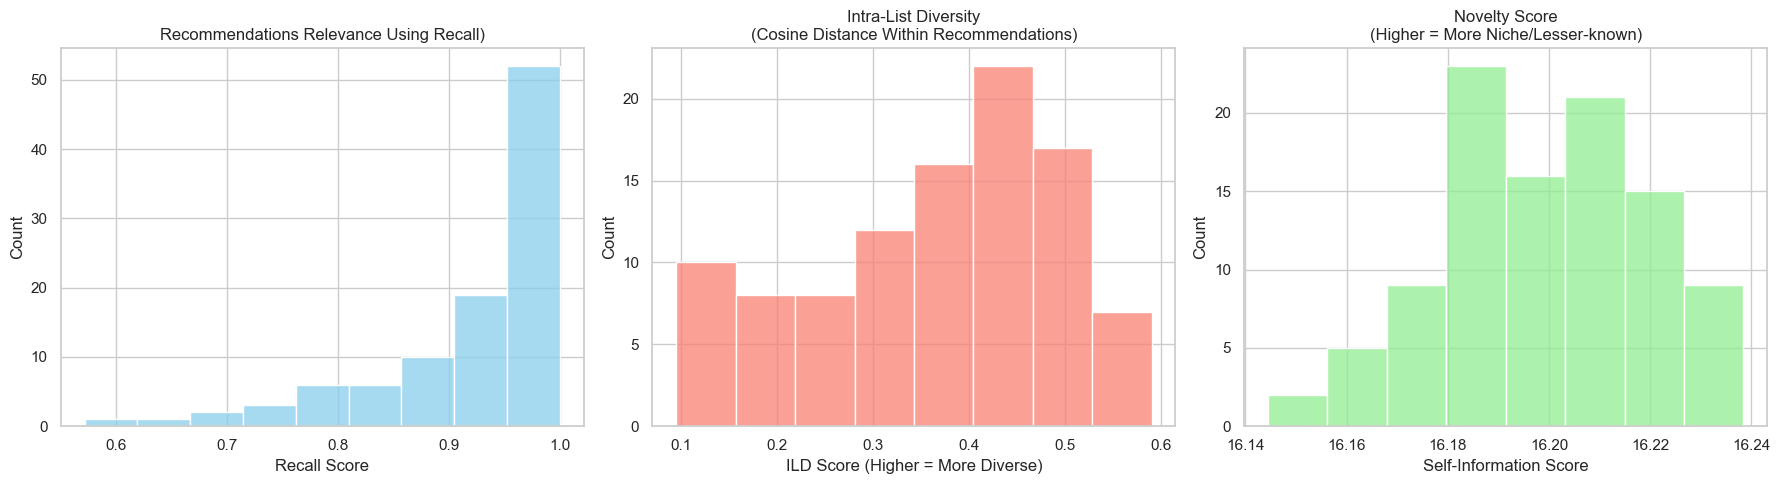

In [461]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Recall
sns.histplot(df_metrics['Recall'], kde = False, ax=axes[0], color='skyblue')
axes[0].set_title('Recommendations Relevance Using Recall)')
axes[0].set_xlabel('Recall Score')
axes[0].set_ylabel('Count')

# Plot 2: Intra-List Diversity
sns.histplot(df_metrics['Intra-List Diversity'], kde = False, ax=axes[1], color='salmon')
axes[1].set_title('Intra-List Diversity\n(Cosine Distance Within Recommendations)')
axes[1].set_xlabel('ILD Score (Higher = More Diverse)')
axes[1].set_ylabel('Count')

# Plot 3: Novelty Distributions
sns.histplot(df_metrics['Novelty (Self-Info)'], kde = False, ax=axes[2], color='lightgreen')
axes[2].set_title('Novelty Score\n(Higher = More Niche/Lesser-known)')
axes[2].set_xlabel('Self-Information Score')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()